<a href="https://colab.research.google.com/github/aluminium5/Hack-O-Week-Sem-V-2026-27/blob/main/Week_3_4_Python_NumPy_Pandas_Visualization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Hack-o-week — Weeks 3 & 4: Python, NumPy, Pandas & Visualization

A hands-on foundation notebook using the real-estate valuation dataset.

## Dataset
This notebook uses **Real estate valuation data set.csv**. The target variable is `Y house price of unit area`.

The dataset contains **414 rows and 8 columns**.

## Learning objectives
- Write and use functions.
- Practice OOP with a small reusable dataset class.
- Use list/dictionary comprehensions.
- Work with NumPy arrays, broadcasting and vectorized operations.
- Clean and transform data with Pandas.
- Use merging and `groupby`.
- Build basic Matplotlib and Seaborn visualizations.

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")

df = pd.read_csv("Real estate valuation data set.csv")
df.head()

,No,X1 transaction date,X2 house age,X3 distance to the nearest MRT station,X4 number of convenience stores,X5 latitude,X6 longitude,Y house price of unit area
0,1,2012.917,32.0,84.87882,10,24.98298,121.54024,37.9
1,2,2012.917,19.5,306.59470,9,24.98034,121.53951,42.2
2,3,2013.583,13.3,561.98450,5,24.98746,121.54391,47.3
3,4,2013.500,13.3,561.98450,5,24.98746,121.54391,54.8
4,5,2012.833,5.0,390.56840,5,24.97937,121.54245,43.1


In [5]:
print(df.shape)
print(df.info())
print(df.isna().sum())
print(df.describe())

(414, 8)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 414 entries, 0 to 413
Data columns (total 8 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   No                                      414 non-null    int64  
 1   X1 transaction date                     414 non-null    float64
 2   X2 house age                            414 non-null    float64
 3   X3 distance to the nearest MRT station  414 non-null    float64
 4   X4 number of convenience stores         414 non-null    int64  
 5   X5 latitude                             414 non-null    float64
 6   X6 longitude                            414 non-null    float64
 7   Y house price of unit area              414 non-null    float64
dtypes: float64(6), int64(2)
memory usage: 26.0 KB
None
No                                        0
X1 transaction date                       0
X2 house age                              0
X3 distan

## 1. Python essentials — functions

In [6]:
def dataset_summary(dataframe):
    return {
        "rows": dataframe.shape[0],
        "columns": dataframe.shape[1],
        "missing_values": int(dataframe.isna().sum().sum()),
        "numeric_columns": dataframe.select_dtypes(include=np.number).columns.tolist()
    }

summary = dataset_summary(df)
summary

{'rows': 414,
 'columns': 8,
 'missing_values': 0,
 'numeric_columns': ['No',
  'X1 transaction date',
  'X2 house age',
  'X3 distance to the nearest MRT station',
  'X4 number of convenience stores',
  'X5 latitude',
  'X6 longitude',
  'Y house price of unit area']}

### List and dictionary comprehensions

In [7]:
numeric_cols = [col for col in df.columns if df[col].dtype != "object"]
column_means = {col: df[col].mean() for col in numeric_cols}
column_means

{'No': np.float64(207.5),
 'X1 transaction date': np.float64(2013.1489710144926),
 'X2 house age': np.float64(17.71256038647343),
 'X3 distance to the nearest MRT station': np.float64(1083.8856889130436),
 'X4 number of convenience stores': np.float64(4.094202898550725),
 'X5 latitude': np.float64(24.969030072463767),
 'X6 longitude': np.float64(121.53336108695655),
 'Y house price of unit area': np.float64(37.980193236714975)}

## 2. OOP — a reusable real-estate dataset class

In [8]:
class RealEstateDataset:
    def __init__(self, dataframe):
        self.data = dataframe.copy()

    def target_mean(self):
        return self.data["Y house price of unit area"].mean()

    def filter_by_mrt_distance(self, max_distance):
        return self.data[
            self.data["X3 distance to the nearest MRT station"] <= max_distance
        ]

    def add_price_category(self):
        target = "Y house price of unit area"
        self.data["price_category"] = pd.qcut(
            self.data[target], q=3, labels=["Low", "Medium", "High"]
        )
        return self.data

real_estate = RealEstateDataset(df)
print("Mean price/unit area:", real_estate.target_mean())
real_estate.add_price_category().head()

Mean price/unit area: 37.980193236714975


,No,X1 transaction date,X2 house age,X3 distance to the nearest MRT station,X4 number of convenience stores,X5 latitude,X6 longitude,Y house price of unit area,price_category
0,1,2012.917,32.0,84.87882,10,24.98298,121.54024,37.9,Medium
1,2,2012.917,19.5,306.59470,9,24.98034,121.53951,42.2,Medium
2,3,2013.583,13.3,561.98450,5,24.98746,121.54391,47.3,High
3,4,2013.500,13.3,561.98450,5,24.98746,121.54391,54.8,High
4,5,2012.833,5.0,390.56840,5,24.97937,121.54245,43.1,Medium


## 3. NumPy — arrays, broadcasting and vectorization

In [9]:
X = df[
    [
        "X2 house age",
        "X3 distance to the nearest MRT station",
        "X4 number of convenience stores"
    ]
].to_numpy()

print("Array shape:", X.shape)
print("First row:", X[0])

Array shape: (414, 3)
First row: [32.      84.87882 10.     ]


In [10]:
# Broadcasting: standardize each selected feature using NumPy operations
feature_mean = X.mean(axis=0)
feature_std = X.std(axis=0)

X_standardized = (X - feature_mean) / feature_std
X_standardized[:5]

array([[ 1.25562833, -0.79249504,  2.00740743],
       [ 0.15708622, -0.61661163,  1.66750286],
       [-0.38779067, -0.41401527,  0.30788458],
       [-0.38779067, -0.41401527,  0.30788458],
       [-1.11722264, -0.54999673,  0.30788458]])

In [11]:
# Vectorized feature: distance in kilometers
distance_m = df["X3 distance to the nearest MRT station"].to_numpy()
distance_km = distance_m / 1000

print(distance_km[:10])
print("Average distance (km):", distance_km.mean())

[0.08487882 0.3065947  0.5619845  0.5619845  0.3905684  2.17503
 0.6234731  0.2876025  5.512038   1.78318   ]
Average distance (km): 1.0838856889130433


## 4. Pandas — cleaning and transformation

In [12]:
clean_df = df.copy()

# Rename columns for easier programming
clean_df = clean_df.rename(columns={
    "X1 transaction date": "transaction_date",
    "X2 house age": "house_age",
    "X3 distance to the nearest MRT station": "mrt_distance",
    "X4 number of convenience stores": "convenience_stores",
    "X5 latitude": "latitude",
    "X6 longitude": "longitude",
    "Y house price of unit area": "house_price"
})

clean_df["transaction_year"] = clean_df["transaction_date"].astype(str).str[:4].astype(int)
clean_df["mrt_distance_km"] = clean_df["mrt_distance"] / 1000

clean_df.head()

,No,transaction_date,house_age,mrt_distance,convenience_stores,latitude,longitude,house_price,transaction_year,mrt_distance_km
0,1,2012.917,32.0,84.87882,10,24.98298,121.54024,37.9,2012,0.084879
1,2,2012.917,19.5,306.59470,9,24.98034,121.53951,42.2,2012,0.306595
2,3,2013.583,13.3,561.98450,5,24.98746,121.54391,47.3,2013,0.561984
3,4,2013.500,13.3,561.98450,5,24.98746,121.54391,54.8,2013,0.561984
4,5,2012.833,5.0,390.56840,5,24.97937,121.54245,43.1,2012,0.390568


## 5. Merging and groupby

In [13]:
# Create a small lookup table and merge it with the main data
store_lookup = pd.DataFrame({
    "convenience_stores": sorted(clean_df["convenience_stores"].unique()),
})
store_lookup["store_level"] = np.select(
    [
        store_lookup["convenience_stores"] <= 3,
        store_lookup["convenience_stores"] <= 7
    ],
    ["Low", "Medium"],
    default="High"
)

merged_df = clean_df.merge(store_lookup, on="convenience_stores", how="left")
merged_df.head()

,No,transaction_date,house_age,mrt_distance,convenience_stores,latitude,longitude,house_price,transaction_year,mrt_distance_km,store_level
0,1,2012.917,32.0,84.87882,10,24.98298,121.54024,37.9,2012,0.084879,High
1,2,2012.917,19.5,306.59470,9,24.98034,121.53951,42.2,2012,0.306595,High
2,3,2013.583,13.3,561.98450,5,24.98746,121.54391,47.3,2013,0.561984,Medium
3,4,2013.500,13.3,561.98450,5,24.98746,121.54391,54.8,2013,0.561984,Medium
4,5,2012.833,5.0,390.56840,5,24.97937,121.54245,43.1,2012,0.390568,Medium


In [14]:
group_summary = (
    merged_df.groupby("store_level")["house_price"]
    .agg(["count", "mean", "median", "min", "max"])
    .sort_values("mean", ascending=False)
)
group_summary

,count,mean,median,min,max
store_level,,,,,
High,65,47.976923,46.60,26.5,78.3
Medium,166,43.705422,42.35,7.6,73.6
Low,183,29.236066,27.30,11.2,117.5


## 6. Visualization — Matplotlib and Seaborn

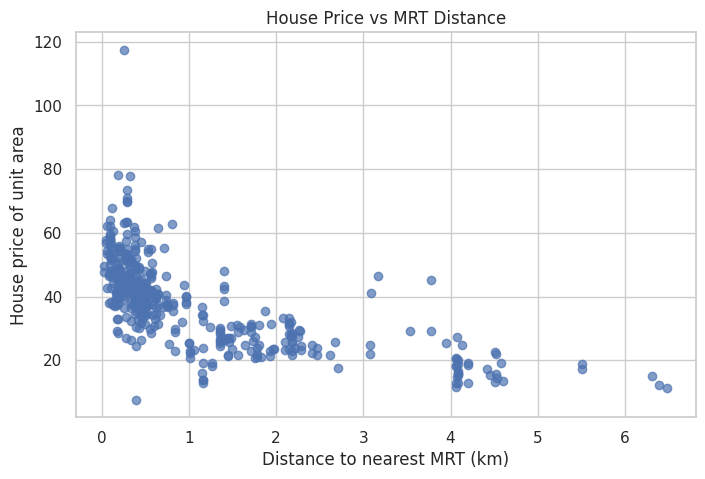

In [15]:
plt.figure(figsize=(8,5))
plt.scatter(clean_df["mrt_distance_km"], clean_df["house_price"], alpha=0.7)
plt.xlabel("Distance to nearest MRT (km)")
plt.ylabel("House price of unit area")
plt.title("House Price vs MRT Distance")
plt.show()

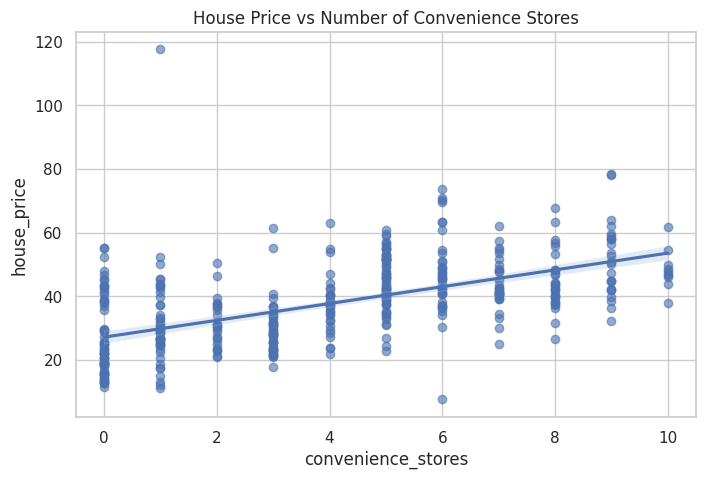

In [16]:
plt.figure(figsize=(8,5))
sns.regplot(
    data=clean_df,
    x="convenience_stores",
    y="house_price",
    scatter_kws={"alpha": 0.6},
    line_kws={}
)
plt.title("House Price vs Number of Convenience Stores")
plt.show()

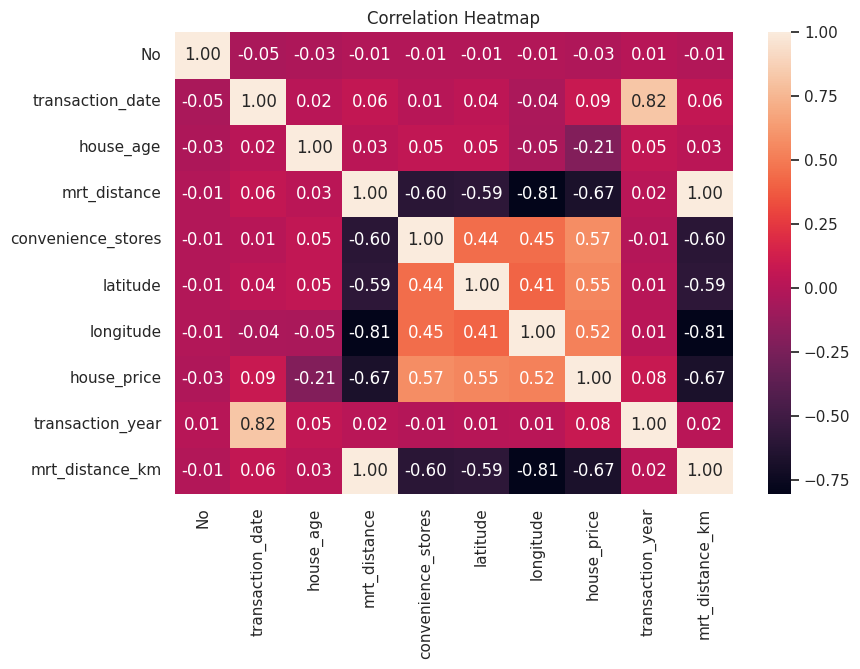

In [17]:
plt.figure(figsize=(9,6))
sns.heatmap(clean_df.corr(numeric_only=True), annot=True, fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

## Week 3–4 mini-task
1. Create a function that returns the top 10 most expensive observations.
2. Add a `price_per_store` feature using vectorized NumPy/Pandas operations.
3. Group prices by transaction year and compare the mean price.
4. Create two additional plots and write 3 observations below them.

## Conclusion
You have completed the Python, NumPy, Pandas and visualization foundations needed for the later machine-learning notebooks.